# 3.3	Algorithme	de	résolution	par	Monte	Carlo		
## Analyse des Choix de Seuil et de Capacité de Batterie

Dans cette section, nous avons effectué une analyse pour déterminer les meilleures configurations de seuil de puissance et de capacité de batterie afin d'optimiser la performance du système. Nous avons utilisé une méthode de Monte Carlo pour échantillonner un grand nombre de configurations possibles et analyser les résultats.

## Paramètres de la Simulation

1. **Nombre d'échantillons (num_samples)**: 1000
2. **Capacités des batteries (capacities)**: Échantillonnées uniformément entre 0 et 14 000 Wh.
3. **Seuils de puissance (seuils)**: Échantillonnées uniformément entre 0 et 1 MW.

## Simulation pour Chaque Échantillon

Pour chaque échantillon, nous avons effectué les étapes suivantes :

1. **Initialisation des Variables**:
   - **E_batterie**: Capacité de la batterie en Wh (convertie de kWh).
   - **Seuil**: Seuil de puissance en W.
   - **E_batterie_actuelle**: Capacité initiale de la batterie (initialisée à 0 Wh).
   - **delta_v_max**: Chute de tension maximale (initialisée à 0).

2. **Simulation Temporelle**:
   - Pour chaque pas de temps, nous avons calculé la puissance demandée par le train (P_train) et le delta de temps (dt).
   - Nous avons géré la charge et la décharge de la batterie en fonction de la puissance demandée et du seuil de puissance.

## Calcul des Résistances et de la Tension

Pour chaque position du train, nous avons calculé les résistances des segments de la ligne aérienne de contact (LAC) et des rails, puis nous avons déterminé la résistance équivalente totale du circuit. Ensuite, nous avons résolu une équation quadratique pour déterminer la tension aux bornes du train et calculer la chute de tension.

## Stockage des Résultats

À la fin de la simulation pour chaque échantillon, nous avons stocké les résultats dans les listes correspondantes :

- **delta_v_max_results**: Chute de tension maximale.
- **capacite_results**: Capacité de la batterie.
- **seuil_results**: Seuil de puissance.

## Visualisation des Résultats

Nous avons utilisé Matplotlib pour visualiser les résultats de la simulation :

1. **Espace des solutions**:
   - Un nuage de points représentant les capacités des batteries et les seuils de puissance échantillonnés.

2. **Espace des objectifs**:
   - Un nuage de points représentant les capacités des batteries et les chutes de tension maximales correspondantes.

## Résultats Obtenus

Les graphiques obtenus montrent :

1. **Espace des solutions** :
   - Une distribution uniforme des capacités des batteries et des seuils de puissance échantillonnés.

2. **Espace des objectifs** :
   - Plusieurs niveaux distincts de chute de tension maximale en fonction des capacités des batteries.
   - Les configurations avec des capacités de batterie plus élevées tendent à avoir des chutes de tension maximales plus faibles.
   - Les configurations avec des seuils de puissance plus élevés peuvent également influencer la chute de tension maximale.

## Meilleures Configurations Identifiées

Parmi les configurations échantillonnées, nous avons identifié les deux meilleures configurations en termes de chute de tension maximale. Ces configurations sont :

1. **Configuration 1** :
   - **Capacité** : 13990.216843617143 Wh
   - **Seuil** : 430538.78955886915 W
   - **Chute de tension maximale** : 82.70968883149794 V

2. **Configuration 2** :
   - **Capacité** : 12371.057561355236 Wh
   - **Seuil** : 451047.14722220594 W
   - **Chute de tension maximale** : 87.20355607262127 V

Ces configurations montrent que des capacités de batterie plus élevées et des seuils de puissance modérés permettent de minimiser la chute de tension maximale, ce qui est crucial pour assurer une performance optimale du système.

## Conclusion

Dans cette partie du code, nous avons utilisé une méthode de Monte Carlo pour échantillonner un grand nombre de configurations de batterie et de seuil de puissance. Nous avons simulé le comportement du système pour chaque configuration et analysé les résultats en termes de chute de tension maximale. Les graphiques obtenus nous permettent de visualiser l'impact des différentes configurations sur la performance du système et de déterminer les meilleurs compromis entre la capacité de la batterie et la chute de tension maximale. Les deux configurations identifiées comme les meilleures montrent que des capacités de batterie plus élevées et des seuils de puissance modérés sont essentiels pour minimiser la chute de tension maximale.


Valeurs correspondantes au front de Pareto:
Capacité: 707.3633526329654 Wh, Seuil: 820355.4814250992 W, Chute de tension maximale: 206.4736742122493 V
Capacité: 6640.613648928517 Wh, Seuil: 494372.20764930977 W, Chute de tension maximale: 96.9184594284211 V
Capacité: 13790.587286008289 Wh, Seuil: 433309.05822285026 W, Chute de tension maximale: 83.3129353950792 V
Capacité: 5178.827411342626 Wh, Seuil: 512397.70927184937 W, Chute de tension maximale: 101.05543818285742 V
Capacité: 2801.7402498008437 Wh, Seuil: 597474.7680133336 W, Chute de tension maximale: 121.42094541307802 V
Capacité: 1277.3060383841341 Wh, Seuil: 768852.6649975462 W, Chute de tension maximale: 185.9033685817294 V
Capacité: 221.80809543568893 Wh, Seuil: 998934.7428566939 W, Chute de tension maximale: 274.7198220145915 V
Capacité: 1636.2683035291839 Wh, Seuil: 735345.2191424003 W, Chute de tension maximale: 158.10990272499168 V
Capacité: 1424.282231793702 Wh, Seuil: 746274.0160098037 W, Chute de tension maximale: 161.

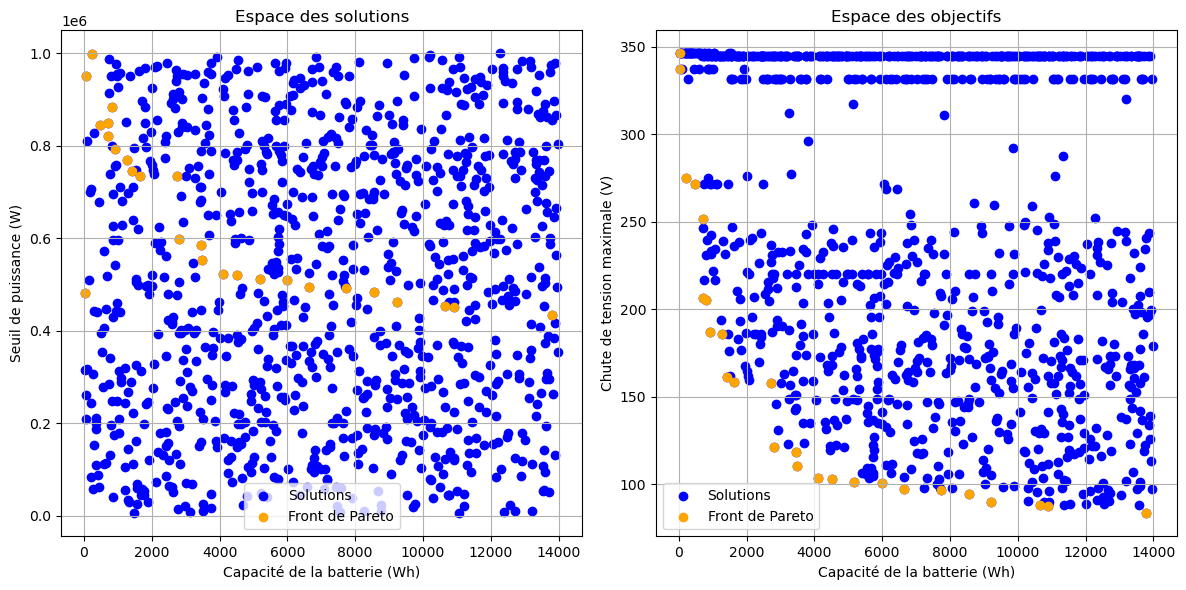

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres de la batterie
rho_LAC = 95e-6  # Résistance linéique de la LAC (Ohm/m)
rho_rail = 10e-6  # Résistance linéique des rails (Ohm/m)
R_internal = 0.01  # Résistance interne de la sous-station (Ohm)
V_source = 790  # Tension de la sous-station (V)

# Échantillonnage de l'espace de décision
num_samples = 1000
capacities = np.random.uniform(0, 14e3, num_samples)  # Capacités des batteries (kWh)
seuils = np.random.uniform(0, 1e6, num_samples)  # Seuils de puissance (W)

# Initialisation des résultats
delta_v_max_results = []
capacite_results = []
seuil_results = []

# Simulation pour chaque échantillon
for i in range(num_samples):
    E_batterie = capacities[i] * 1e3  # Convertir en Wh
    Seuil = seuils[i]  # Seuil de puissance en W
    E_batterie_actuelle = E_batterie  # Capacité initiale de la batterie (Wh)
    delta_v_max = 0

    # Simulation temporelle
    for j in range(len(time)):
        x_pos = position[j]  # Position actuelle du train
        P_train = P_electrique_results[j]  # Puissance demandée par le train
        dt = time[j] - time[j - 1] if j > 0 else 1  # Delta de temps (approximation pour le premier point)

        if P_train < 0:  # Recharge (freinage)
            if E_batterie_actuelle < E_batterie:
                P_lac = 0  # Pas de puissance fournie par la sous-station
                P_rh = 0  # Rhéostat inactif
                P_batt = P_train  # Recharge de la batterie
                E_batterie_actuelle -= P_batt * dt * 0.9  # Prendre en compte le rendement de la batterie
            else:
                P_lac = 0
                P_batt = 0  # La batterie ne peut plus être chargée
                P_rh = -P_train  # Le rhéostat dissipe toute la puissance de freinage
        elif P_train >= 0:  # Décharge (consommation)
            if P_train <= Seuil:
                P_lac = P_train  # La sous-station fournit toute la puissance
                P_batt = 0  # Pas de décharge de la batterie
                P_rh = 0
            else:
                P_lac = Seuil  # La sous-station fournit au maximum jusqu'au seuil
                P_rh = 0
                if E_batterie_actuelle > 0:
                    P_batt = P_train - P_lac  # La batterie complète la puissance
                    # Limiter si l'énergie de la batterie est insuffisante
                    max_batt_power = E_batterie_actuelle * 0.9 / dt
                    if P_batt > max_batt_power:
                        P_batt = max_batt_power
                    E_batterie_actuelle -= P_batt * dt / 0.9  # Mise à jour de l'énergie de la batterie
                else:
                    P_batt = 0  # Batterie vide
                P_lac = P_train - P_batt  # Recalculer la puissance sous-station

        # Calcul des résistances des segments
        R_LAC1 = rho_LAC * x_pos  # Résistance de la première branche de la LAC
        R_rail1 = rho_rail * x_pos  # Résistance de la première branche des rails
        R_LAC2 = rho_LAC * (position[-1] - x_pos)  # Résistance de la deuxième branche de la LAC
        R_rail2 = rho_rail * (position[-1] - x_pos)  # Résistance de la deuxième branche des rails

        # Résistance équivalente de chaque branche
        R_haut = R_LAC1 + R_rail1 + R_internal
        R_bas = R_LAC2 + R_rail2 + R_internal
        R_eq = (R_haut * R_bas) / (R_haut + R_bas)  # Résistance équivalente

        # Calcul de la tension aux bornes du train
        discriminant = V_source**2 - 4 * R_eq * (P_lac)
        if discriminant >= 0:
            V_train = (V_source + np.sqrt(discriminant)) / 2
        else:
            V_train = 500  # Valeur par défaut si le discriminant est négatif

        delta_v = abs(V_source - V_train)
        if delta_v > delta_v_max:
            delta_v_max = delta_v

    # Stockage des résultats
    delta_v_max_results.append(delta_v_max)
    capacite_results.append(capacities[i])
    seuil_results.append(seuils[i])

# Détermination du front de Pareto
def is_dominated(candidate, pareto_front):
    for point in pareto_front:
        if (point[0] <= candidate[0] and point[1] <= candidate[1]) and (point[0] < candidate[0] or point[1] < candidate[1]):
            return True
    return False

pareto_front = []
for i in range(num_samples):
    candidate = (capacite_results[i], delta_v_max_results[i])
    if not is_dominated(candidate, pareto_front):
        pareto_front.append(candidate)
        pareto_front = [point for point in pareto_front if not is_dominated(point, [candidate])]

# Séparation des points du front de Pareto
pareto_capacities = [point[0] for point in pareto_front]
pareto_delta_v_max = [point[1] for point in pareto_front]

# Identification des points correspondants dans l'espace des solutions
pareto_seuils = []
pareto_indices = []
for capacity in pareto_capacities:
    index = capacite_results.index(capacity)
    pareto_seuils.append(seuil_results[index])
    pareto_indices.append(index)

# Affichage des valeurs correspondantes au front de Pareto
print("Valeurs correspondantes au front de Pareto:")
for i in pareto_indices:
    print(f"Capacité: {capacite_results[i]} Wh, Seuil: {seuil_results[i]} W, Chute de tension maximale: {delta_v_max_results[i]} V")

# Visualisation des résultats
plt.figure(figsize=(12, 6))

# Espace des solutions
plt.subplot(1, 2, 1)
plt.scatter(capacite_results, seuil_results, c='blue', label='Solutions')
plt.scatter(pareto_capacities, pareto_seuils, c='orange', label='Front de Pareto')
plt.xlabel('Capacité de la batterie (Wh)')
plt.ylabel('Seuil de puissance (W)')
plt.title('Espace des solutions')
plt.legend()
plt.grid()

# Espace des objectifs
plt.subplot(1, 2, 2)
plt.scatter(capacite_results, delta_v_max_results, c='blue', label='Solutions')
plt.scatter(pareto_capacities, pareto_delta_v_max, c='orange', label='Front de Pareto')
plt.xlabel('Capacité de la batterie (Wh)')
plt.ylabel('Chute de tension maximale (V)')
plt.title('Espace des objectifs')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()
